# Titanic Data — Matplotlib for Beginners

**What is Matplotlib?**
Matplotlib is a drawing tool for Python.
It turns your numbers into bar charts, line graphs, pie charts, and more.

**Real-world example:**
After analyzing eSewa's monthly transactions in a table,
you show the results as a bar chart to the CEO.
Charts make data easy to understand — that is what Matplotlib does.

**In this notebook:**
- Learn each chart type with a simple example
- Apply each chart to real Titanic data
- Learn how to add titles, labels, and colors

In [2]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # This line makes charts appear directly in the notebook
# %matplotlib inline

# # Load and clean the Titanic data
df = pd.read_csv('titanic_cleaned.csv')
# df['Age']  = df['Age'].fillna(df['Age'].median()).round(0)
# df['Fare'] = df['Fare'].fillna(df['Fare'].median()).round(2)

# # Add useful columns we will use for charts
# df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# df['AgeGroup']   = df['Age'].apply(lambda x: 'Child' if x < 18 else ('Senior' if x >= 60 else 'Adult'))
# df['Name']       = df['Name'].str.replace('"', '', regex=False).str.strip()

# print('Data ready for visualization!')
# print('Shape:', df.shape)

---
## How Every Matplotlib Chart is Built

Every chart follows this same 4-step pattern:
1. `plt.figure(figsize=(width, height))` — create a blank canvas
2. `plt.bar()` or `plt.plot()` etc. — draw the chart
3. `plt.title()`, `plt.xlabel()`, `plt.ylabel()` — add labels
4. `plt.show()` — display the chart

---
# CHART 1: BAR CHART
**When to use:** Compare values across categories
**Example:** Sales per branch, passengers per class

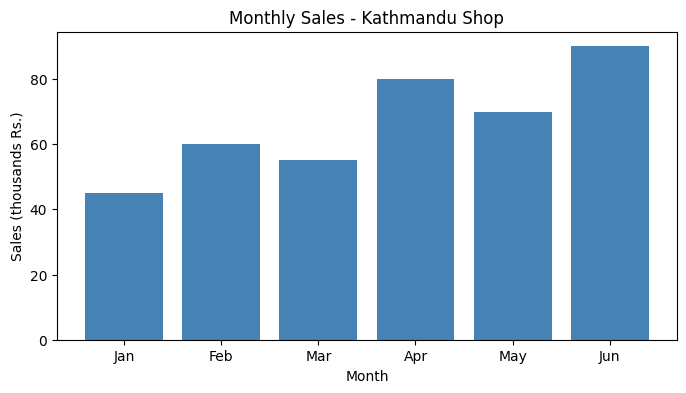

In [3]:
# Simple bar chart — practice with fake data first
# Monthly sales of a Kathmandu shop

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
sales  = [45, 60, 55, 80, 70, 90]

plt.figure(figsize=(8, 4))                    # set chart size (width=8, height=4 inches)
plt.bar(months, sales, color='steelblue')     # draw bars, Each month gets a bar with height equal to its sales
plt.title('Monthly Sales - Kathmandu Shop')  # chart title
plt.xlabel('Month')                           # label for X axis (bottom)
plt.ylabel('Sales (thousands Rs.)')           # label for Y axis (left side)
plt.show()                                    # display the chart

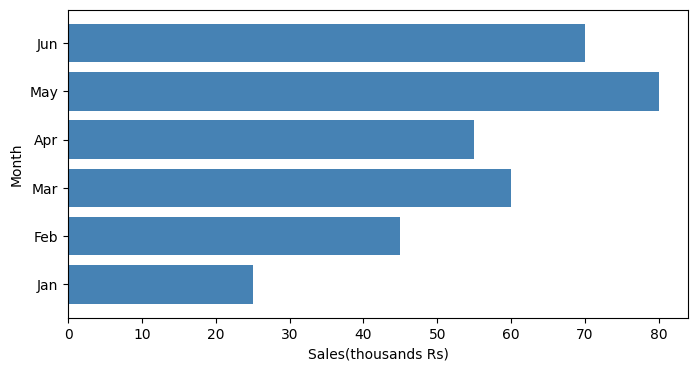

In [30]:
months = ['Jan','Feb','Mar','Apr','May','Jun']
sales = [25,45,60,55,80,70]

plt.figure(figsize=(8,4)) # set chart size(width, height in inches)
plt.barh(months, sales, color = 'steelblue') # y, x
plt.ylabel('Month')
plt.xlabel('Sales(thousands Rs)')
plt.show()

Pclass
1    107
2     93
3    218
Name: count, dtype: int64


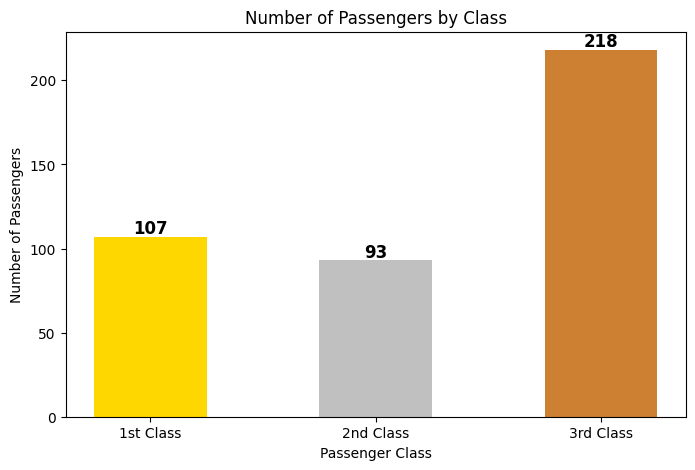

In [ ]:
# Bar chart with Titanic data — Passengers per class

class_counts = df['Pclass'].value_counts().sort_index()

print(class_counts)

# value_counts() → counts how many passengers are in each class
# sort_index() → ensures order is 1 → 2 → 3 (instead of random)

class_labels = ['1st Class', '2nd Class', '3rd Class']

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['gold', 'silver', '#CD7F32'], width=0.5)
# gold=1st, silver=2nd, bronze(#CD7F32)=3rd — like medals!

plt.title('Number of Passengers by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

# Add the exact number on top of each bar
for i, count in enumerate(class_counts):
    plt.text(i, count + 2, str(count), ha='center', fontsize=12, fontweight='bold')  # x position is i and y position is count + 2
    # plt.text(i, count + 2, f'{count}', ha='center', fontweight = 'bold')

plt.show()


# enumerate() give me both the index and the value while looping
# str(count) = Converts number to string
#  ha='center' Horizontal alignment = center

# | Iteration | `i` (x-position) | `count` (bar height) |
# | --------- | ---------------- | -------------------- |
# | 1         | 0                | 107                  |
# | 2         | 1                | 93                   |
# | 3         | 2                | 218                  |


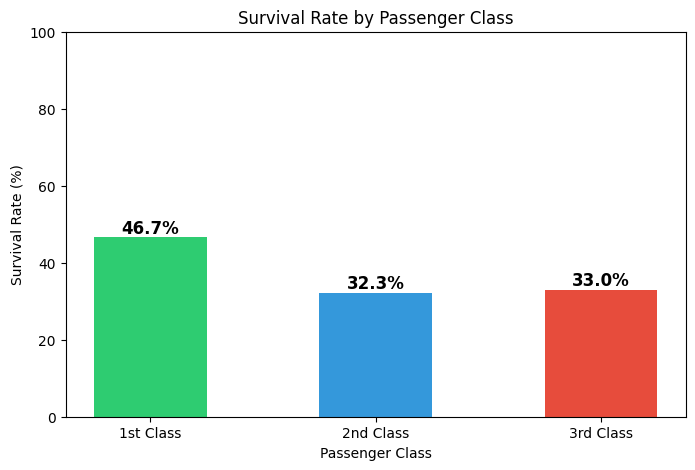

In [32]:
# Bar chart — Survival rate by class (in percentage)

survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
class_labels      = ['1st Class', '2nd Class', '3rd Class']
colors            = ['#2ecc71', '#3498db', '#e74c3c']   # green, blue, red

plt.figure(figsize=(8, 5))
plt.bar(class_labels, survival_by_class.values, color=colors, width=0.5) #plt.bar determine the vertical chart

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)   # Y axis from 0 to 100 percent

# Add % label on each bar
for i, val in enumerate(survival_by_class.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.show()

---
# CHART 2: HORIZONTAL BAR CHART
**When to use:** When category names are long, horizontal bars are easier to read
**Example:** Top performers list, long product names

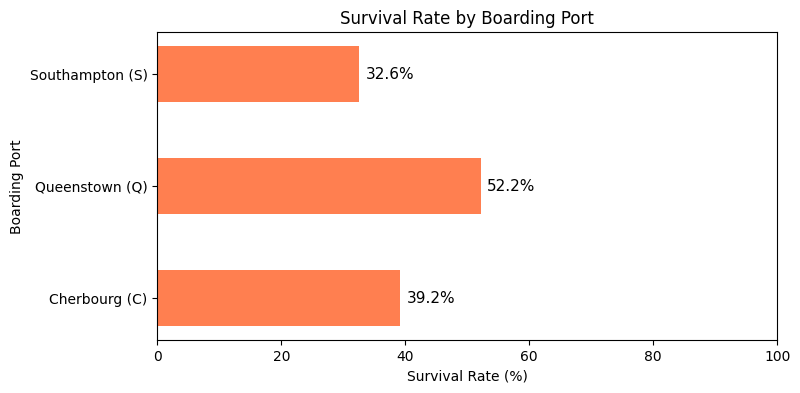

In [ ]:
# Horizontal bar chart — Survival rate by boarding port

port_survival = df.groupby('Embarked')['Survived'].mean() * 100

# | Port | Survived values | Mean |
# | ---- | --------------- | ---- |
# | C    | [1, 1, 0, 1]    | 0.75 |
# | Q    | [0, 0, 1]       | 0.33 |
# | S    | [0, 1, 0, 0]    | 0.25 |

port_labels   = ['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)']

plt.figure(figsize=(8, 4))

# barh() = horizontal bar (bar going sideways)
# port_labels go on the y-axis (vertical axis)
# port_survival.values go on the x-axis (horizontal axis)
plt.barh(port_labels, port_survival.values, color='coral', height=0.5)


plt.title('Survival Rate by Boarding Port')
plt.xlabel('Survival Rate (%)')       # now xlabel is on bottom
plt.ylabel('Boarding Port')           # ylabel is on left
plt.xlim(0, 100)

# Add label at the end of each bar
for i, val in enumerate(port_survival.values):
    plt.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=11)

plt.show()

---
# CHART 3: PIE CHART
**When to use:** Show parts of a whole (percentages that add to 100%)
**Example:** Market share, gender split, class distribution

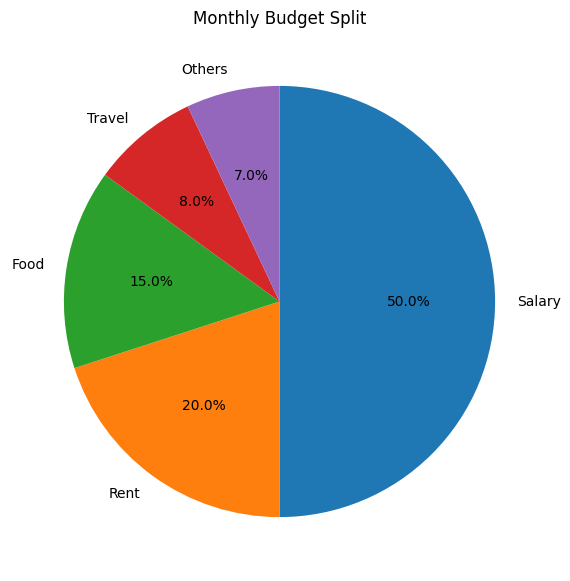

In [29]:
# Simple pie chart — budget split example

categories = ['Salary', 'Rent', 'Food', 'Travel', 'Others']
amounts    = [50, 20, 15, 8, 7]

plt.figure(figsize=(7, 7))
plt.pie(
    amounts,
    labels    = categories,
    autopct   = '%.1f%%',     # show % on each slice, %% → prints the % symbol
    startangle = 90  ,         # start from top (12 o'clock position) 
    counterclock=False         # by default it rotates anticlockwise in Matplotlib
)
plt.title('Monthly Budget Split')
plt.show()

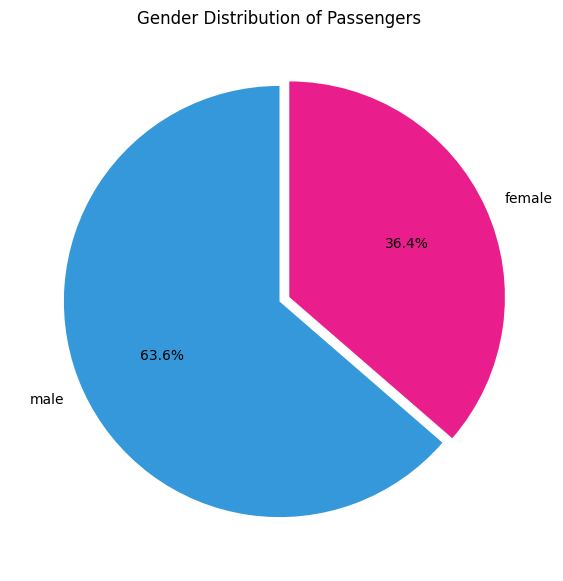

In [37]:
# Pie chart — Gender distribution in Titanic

gender_counts = df['Sex'].value_counts()

plt.figure(figsize=(7, 7))
# plt.pie(
#     gender_counts.values,
#     labels    = ['Male', 'Female'],
#     colors    = ['#3498db', '#e91e8c'],     # blue for male, pink for female
#     autopct   = '%1.1f%%',
#     startangle = 90,
#     explode   = (0, 0.05)                   # slightly pull out the female slice
# )

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    colors=['#3498db', '#e91e8c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
plt.title('Gender Distribution of Passengers')
plt.show()

---
# CHART 4: LINE CHART
**When to use:** Show trends over time or ordered sequence
**Example:** Monthly sales trend, age vs fare pattern

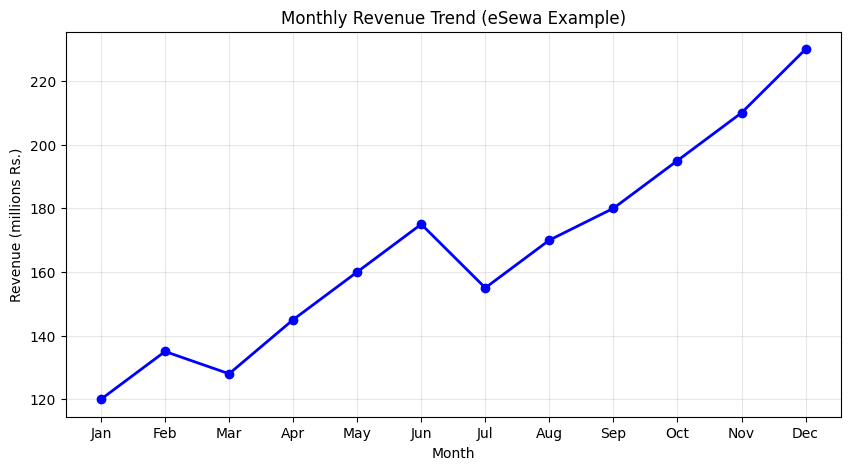

In [ ]:
# Simple line chart — monthly revenue trend

months  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
revenue = [120, 135, 128, 145, 160, 175, 155, 170, 180, 195, 210, 230]

plt.figure(figsize=(10, 5)) # 10 inches wide, 5 inches height
plt.plot(months, revenue, color='blue',linestyle='-' ,linewidth=2, marker='o') # (x,y,color, thickness of the line,place a dot at each data point)
# linewidth = thickness of the line
# marker='o' = put a dot at each data point, we can use other markers as s,^,*
# linestyles = '--',':','-.','-'

plt.title('Monthly Revenue Trend (eSewa Example)')
plt.xlabel('Month')
plt.ylabel('Revenue (millions Rs.)')
plt.grid(True, alpha=0.3) # add faint grid lines for readability, alpha varies from 0 to 1
plt.show()

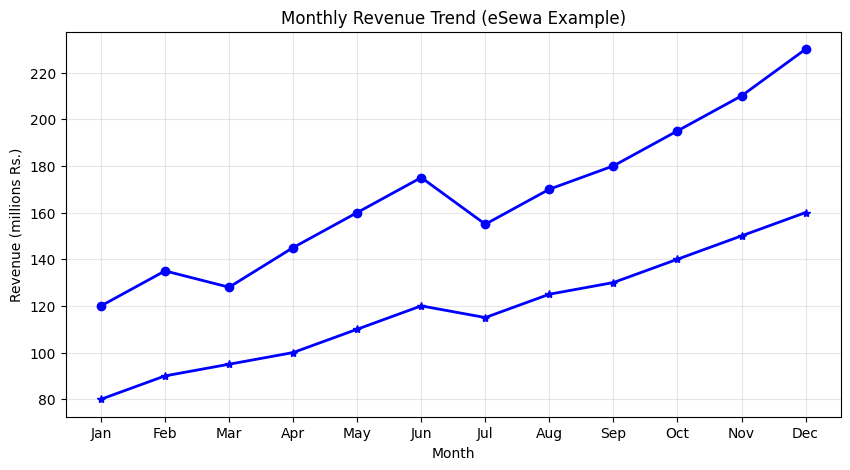

In [ ]:
# Simple line chart — monthly revenue trend

months  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
revenue_1 = [120, 135, 128, 145, 160, 175, 155, 170, 180, 195, 210, 230]
revenue_2 = [80,  90,  95,  100, 110, 120, 115, 125, 130, 140, 150, 160]

plt.figure(figsize=(10, 5)) # 10 inches wide, 5 inches height
plt.plot(months, revenue_1, color='blue',linestyle='-' ,linewidth=2, marker='o', label = 'revenue_1') # (x,y,color, thickness of the line,place a dot at each data point)
plt.plot(months, revenue_2, color='blue',linestyle='-' ,linewidth=2, marker='*', label = 'revenue_2')
# linewidth = thickness of the line
# marker='o' = put a dot at each data point, we can use other markers as s,^,*
# linestyles = '--',':','-.','-'

plt.title('Monthly Revenue Trend (eSewa Example)')
plt.xlabel('Month')
plt.ylabel('Revenue (millions Rs.)')
plt.grid(True, alpha=0.3)  # add faint grid lines for readability, alpha varies from 0 to 1
plt.show()

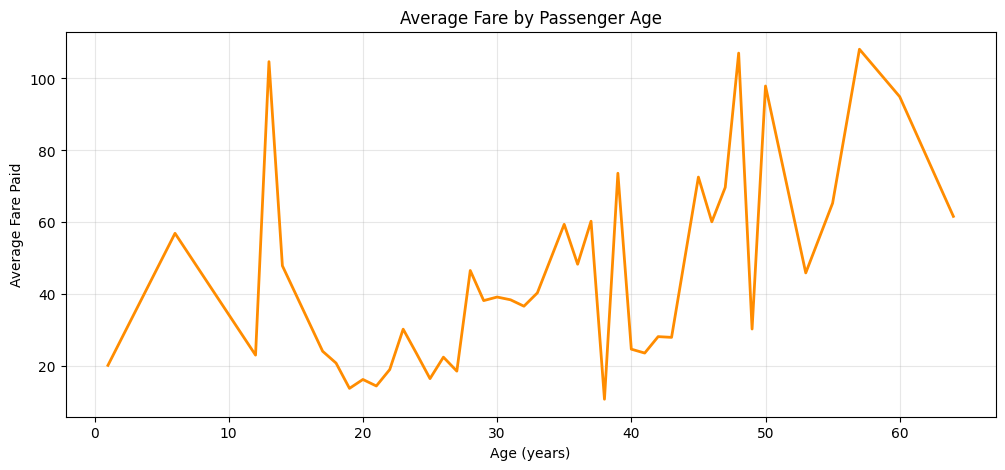

In [80]:
# Line chart — Average fare across age groups (sorted by age)
# This shows if older passengers paid more on average

# Group by age and get average fare
# Only include ages that appear more than 2 times (avoid noise)
age_fare = df.groupby('Age')['Fare'].mean()
age_fare = age_fare[df['Age'].value_counts() > 2]
plt.figure(figsize=(12, 5))
plt.plot(age_fare.index, age_fare.values, color='darkorange', linewidth=2)

plt.title('Average Fare by Passenger Age')
plt.xlabel('Age (years)')
plt.ylabel('Average Fare Paid')
plt.grid(True, alpha=0.3) # add faint grid lines for readability, alpha varies from 0 to 1
plt.show()

---
# CHART 5: HISTOGRAM
**When to use:** Show distribution of a single number column
**Example:** Age distribution, salary spread, exam score distribution

Use a histogram when you have many numbers and want to see where most of them are concentrated. "How many values fall within each range?"

bar char have labels in x axis but histogram have numeric range in the x axis

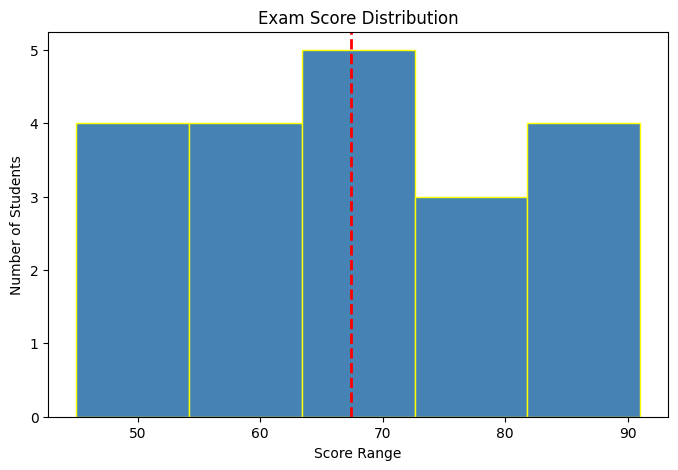

In [68]:
# Simple histogram — exam score distribution

import numpy as np
# scores = np.array([45, 52, 67, 73, 58, 82, 91, 64, 78, 55,
#                    70, 63, 48, 85, 72, 60, 76, 88, 53, 69])

scores = [45, 52, 67, 73, 58, 82, 91, 64, 78, 55,
                   70, 63, 48, 85, 72, 60, 76, 88, 53, 69]

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=5, color='steelblue', edgecolor='yellow')
plt.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2)
# bins=5 means divide the data into 5 groups
# edgecolor='white' adds white lines between bars to separate them

# plt.hist(scores, bins=[0, 40, 50, 60, 80, 100], color='steelblue', edgecolor='yellow')  # set the bin range on own

plt.title('Exam Score Distribution')
plt.xlabel('Score Range')
plt.ylabel('Number of Students')
plt.show()

# x axis part show 45 to 50, 50 to 60,.... i.e left include right excludes

# use patches to make the individual color of each bar

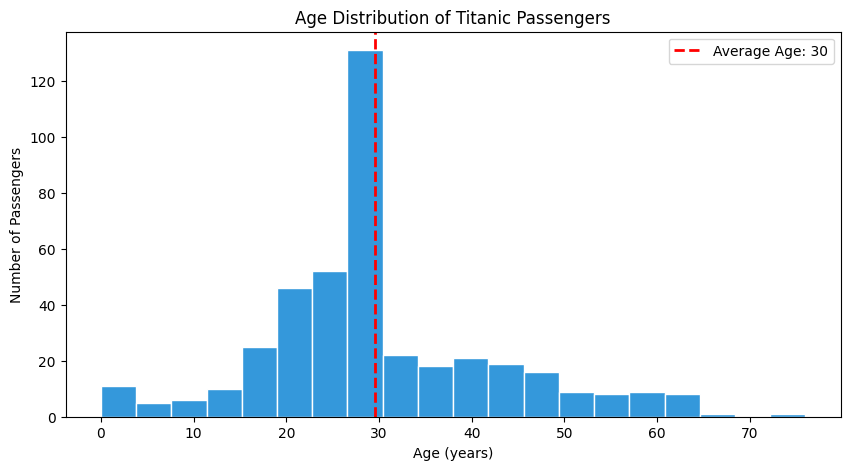

In [74]:
# Histogram — Age distribution of Titanic passengers

plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=20, color='#3498db', edgecolor='white')
# bins=20 = divide all ages into 20 groups

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age (years)')
plt.ylabel('Number of Passengers')

# Add a vertical line for the average age
avg_age = df['Age'].mean()
plt.axvline(avg_age, color='red', linewidth=2, linestyle='--', label=f'Average Age: {avg_age:.0f}')

# {avg_age:.0f} → formats the number to 0 decimal places (rounded integer)
# So if avg_age = 27.6, it shows: Average Age: 28

plt.legend()   # show the legend (explanation box)

plt.show()

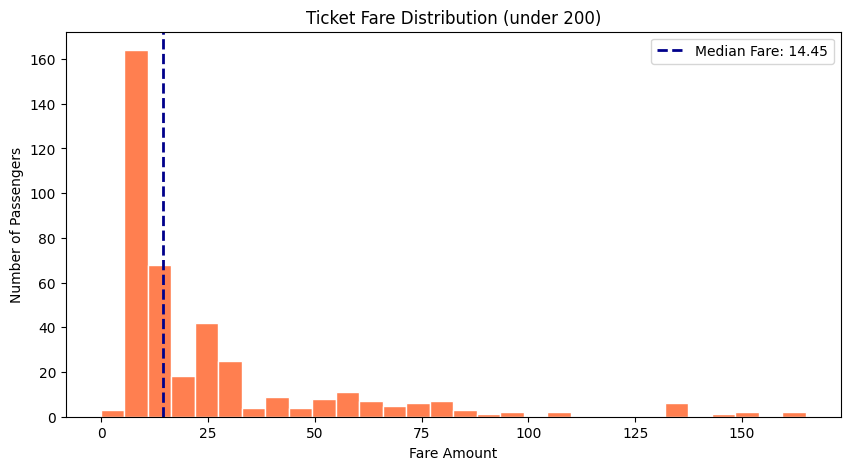

In [14]:
# Histogram — Fare distribution
# We limit to fares below 200 to avoid extreme values dominating the chart

fares_filtered = df[df['Fare'] < 200]['Fare']

plt.figure(figsize=(10, 5))
plt.hist(fares_filtered, bins=30, color='coral', edgecolor='white')

plt.title('Ticket Fare Distribution (under 200)')
plt.xlabel('Fare Amount')
plt.ylabel('Number of Passengers')

# Median line
median_fare = df['Fare'].median()
plt.axvline(median_fare, color='darkblue', linewidth=2, linestyle='--', label=f'Median Fare: {median_fare:.2f}')
plt.legend()

plt.show()

---
# CHART 6: SCATTER PLOT
**When to use:** See relationship between two number columns
**Example:** Age vs Fare — do older people pay more?

Use a scatter plot when you want to check — does one thing affect another thing?

Like e.g Does more experience actually lead to higher salary in our company?

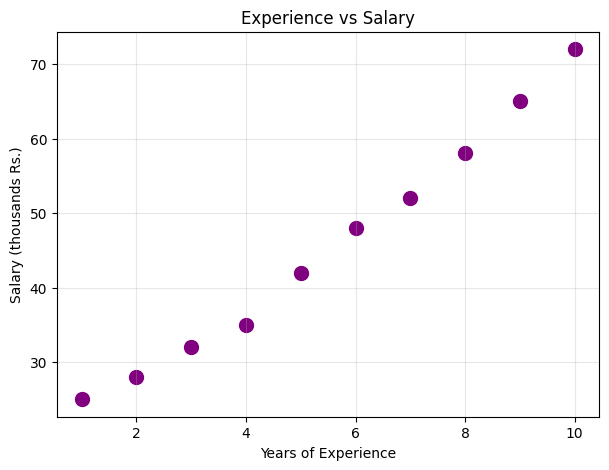

In [78]:
# Simple scatter plot — experience vs salary

experience = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
salary     = [25, 28, 32, 35, 42, 48, 52, 58, 65, 72]

plt.figure(figsize=(7, 5))
plt.scatter(experience, salary, color='purple', s=100)
# s=100 controls the size of each dot

plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (thousands Rs.)')
plt.grid(True, alpha=0.3)
plt.show()

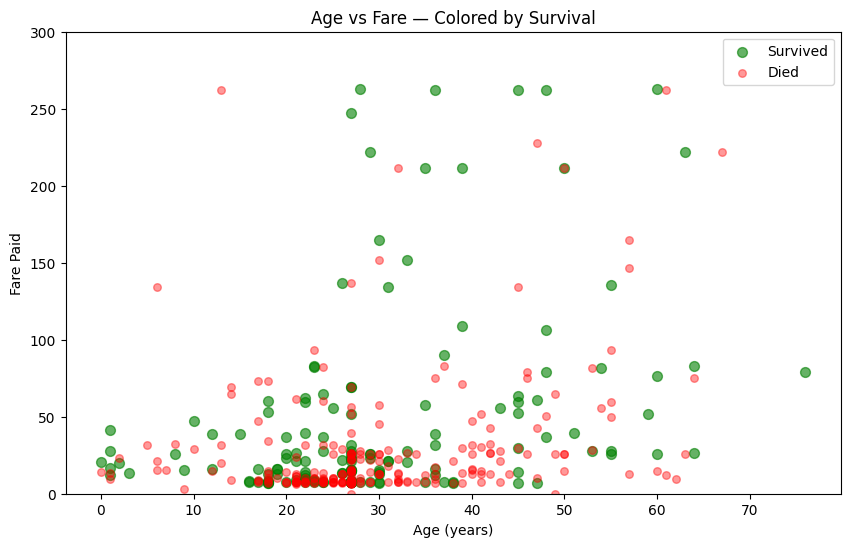

In [16]:
# Scatter plot — Age vs Fare, colored by Survived
# Green dots = survived | Red dots = died

survived_df = df[df['Survived'] == 1]
died_df     = df[df['Survived'] == 0]

plt.figure(figsize=(10, 6))

# Plot survivors (green)
plt.scatter(survived_df['Age'], survived_df['Fare'],
            color='green', alpha=0.6, s=50, label='Survived')

# Plot who died (red) on same chart
plt.scatter(died_df['Age'], died_df['Fare'],
            color='red', alpha=0.4, s=30, label='Died')

# alpha = transparency (0=invisible, 1=solid)

plt.title('Age vs Fare — Colored by Survival')
plt.xlabel('Age (years)')
plt.ylabel('Fare Paid')
plt.legend()
plt.ylim(0, 300)    # limit Y to 300 to avoid extreme values
plt.show()

---
# CHART 7: MULTIPLE CHARTS IN ONE FIGURE (Subplots)
**When to use:** Show multiple charts together — like a dashboard

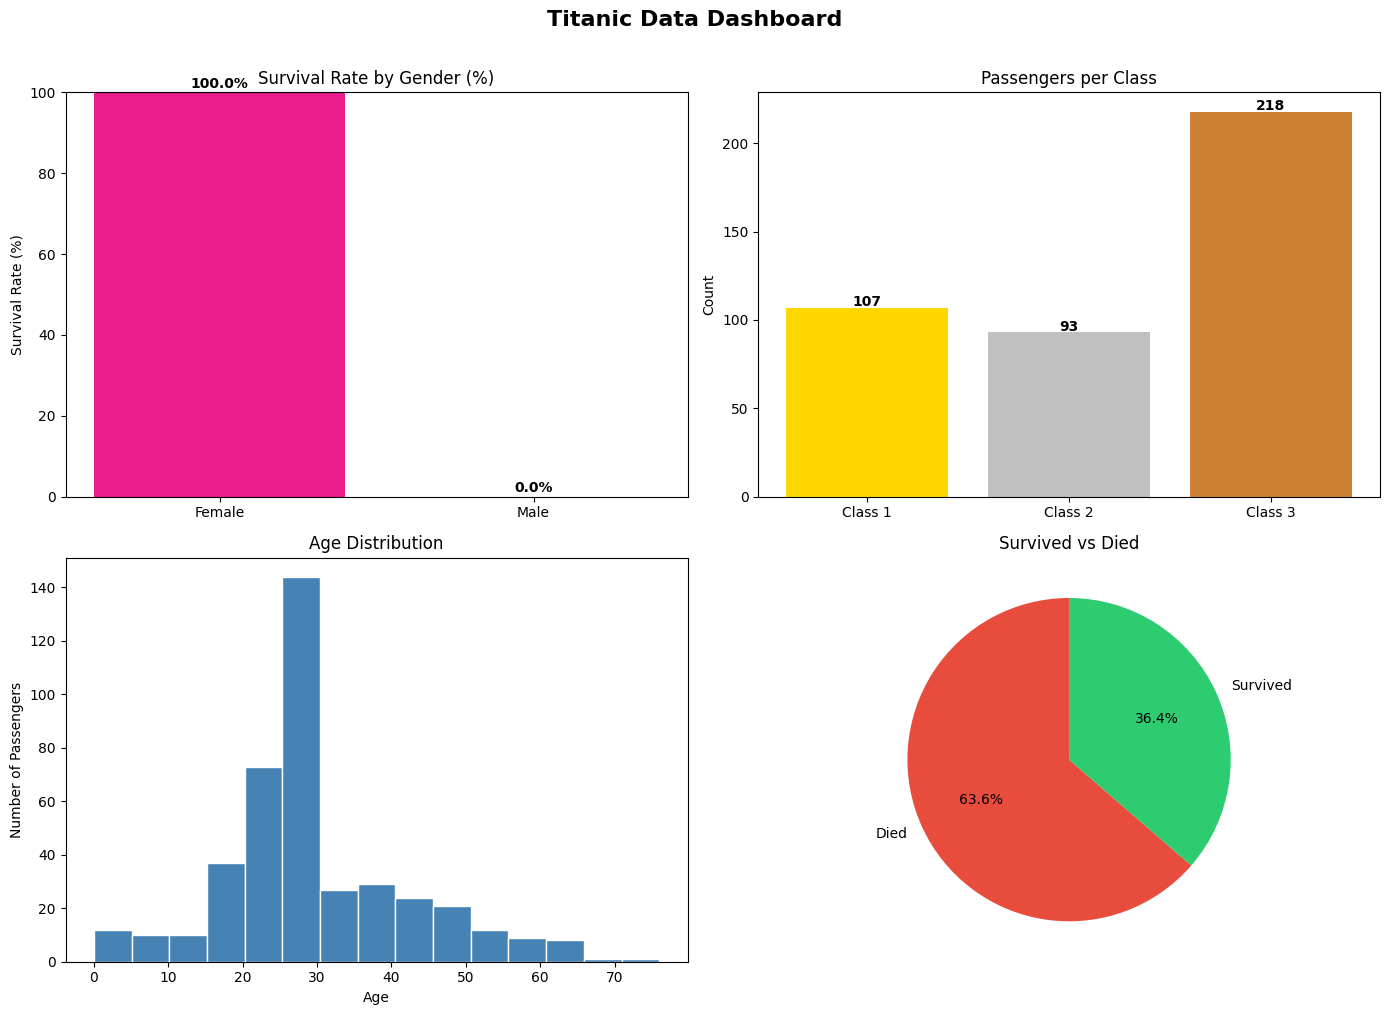

In [17]:
# Show 4 charts together on one page
# plt.subplot(rows, columns, position)
# Like a grid — 2 rows x 2 columns = 4 chart spots

plt.figure(figsize=(14, 10))

# ----- Chart 1 (top-left): Survival by Gender -----
plt.subplot(2, 2, 1)    # row 2, col 2, position 1
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
plt.bar(['Female', 'Male'], gender_survival.values, color=['#e91e8c', '#3498db'])
plt.title('Survival Rate by Gender (%)')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
for i, v in enumerate(gender_survival.values):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# ----- Chart 2 (top-right): Passengers per Class -----
plt.subplot(2, 2, 2)    # row 2, col 2, position 2
class_counts = df['Pclass'].value_counts().sort_index()
plt.bar(['Class 1', 'Class 2', 'Class 3'], class_counts.values, color=['gold', 'silver', '#CD7F32'])
plt.title('Passengers per Class')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v+1, str(v), ha='center', fontweight='bold')

# ----- Chart 3 (bottom-left): Age Distribution -----
plt.subplot(2, 2, 3)    # row 2, col 2, position 3
plt.hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

# ----- Chart 4 (bottom-right): Survived vs Died Pie -----
plt.subplot(2, 2, 4)    # row 2, col 2, position 4
survived_counts = df['Survived'].value_counts()
plt.pie(survived_counts.values,
        labels=['Died', 'Survived'],
        colors=['#e74c3c', '#2ecc71'],
        autopct='%1.1f%%', startangle=90)
plt.title('Survived vs Died')

plt.suptitle('Titanic Data Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()    # automatically adjust spacing between charts
plt.show()

---
# CHART 8: GROUPED BAR CHART
**When to use:** Compare multiple groups side by side
**Example:** Male vs Female survival per class

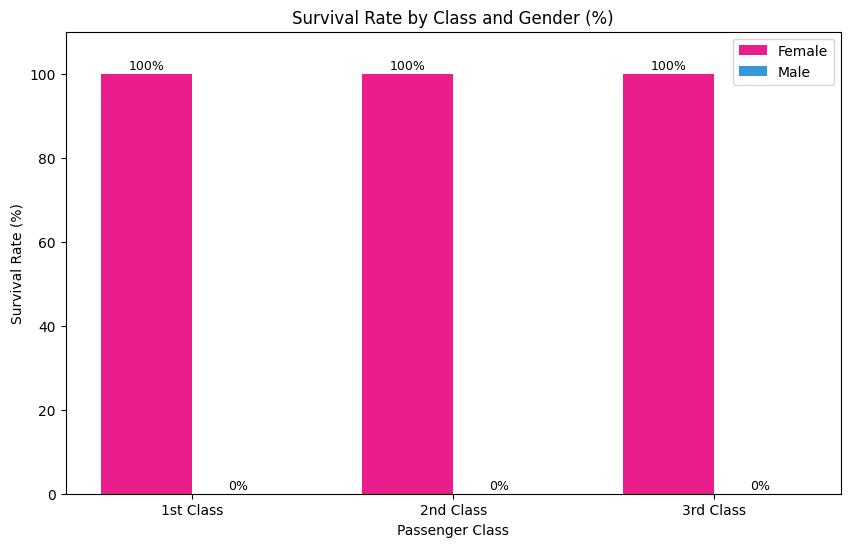

In [18]:
# Grouped bar chart — Survival rate by class AND gender

# Prepare data — pivot table gives us a nice format
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
pivot = pivot.unstack()   # unstack() spreads Sex values into columns

class_labels = ['1st Class', '2nd Class', '3rd Class']

# Position of bars on X axis
x = np.arange(len(class_labels))   # [0, 1, 2]
width = 0.35                         # width of each bar

plt.figure(figsize=(10, 6))

# Female bars — shifted slightly LEFT
plt.bar(x - width/2, pivot['female'], width, label='Female', color='#e91e8c')

# Male bars — shifted slightly RIGHT
plt.bar(x + width/2, pivot['male'],   width, label='Male',   color='#3498db')

plt.title('Survival Rate by Class and Gender (%)')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(x, class_labels)    # set x-axis labels
plt.legend()
plt.ylim(0, 110)

# Add values on bars
for i, (f, m) in enumerate(zip(pivot['female'], pivot['male'])):
    plt.text(i - width/2, f+1, f'{f:.0f}%', ha='center', fontsize=9)
    plt.text(i + width/2, m+1, f'{m:.0f}%', ha='center', fontsize=9)

plt.show()

---
# CHART 9: SAVING A CHART AS AN IMAGE FILE

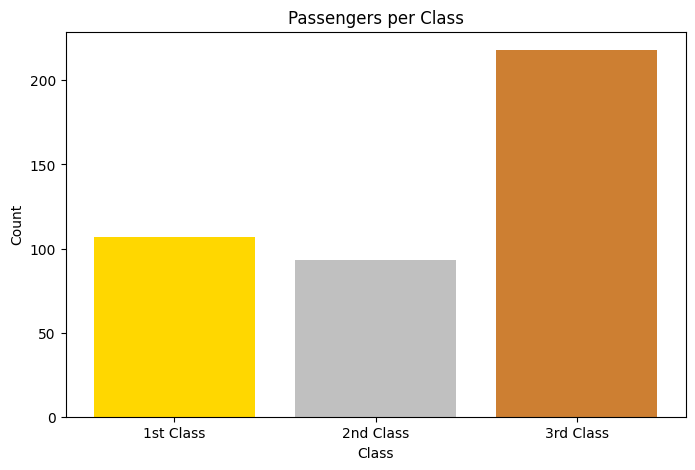

Chart saved as titanic_class_chart.png


In [ ]:
# You can save any chart as a PNG image file
# plt.savefig() saves BEFORE plt.show()

class_counts  = df['Pclass'].value_counts().sort_index()
class_labels  = ['1st Class', '2nd Class', '3rd Class']

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color=['gold', 'silver', '#CD7F32'])
plt.title('Passengers per Class')
plt.xlabel('Class')
plt.ylabel('Count')

# Save as PNG image — dpi=150 means higher quality image
plt.savefig('titanic_class_chart.png', dpi=150, bbox_inches='tight')

# 'titanic_class_chart.png' — the filename and format. The extension you write decides the file format
# dpi=150 — stands for Dots Per Inch — controls the image quality/resolution:
#         dpi=72    # low quality  — small file size
#         dpi=100   # default      — okay for screen viewing
#         dpi=150   # good quality — recommended for most uses
#         dpi=300   # high quality — use for printing or professional reports

# bbox_inches='tight' — removes unnecessary white space around the chart

plt.show()
print('Chart saved as titanic_class_chart.png')

---
# CHART 10: FULL ANALYSIS DASHBOARD
A 6-chart dashboard summarizing all key insights from the Titanic data

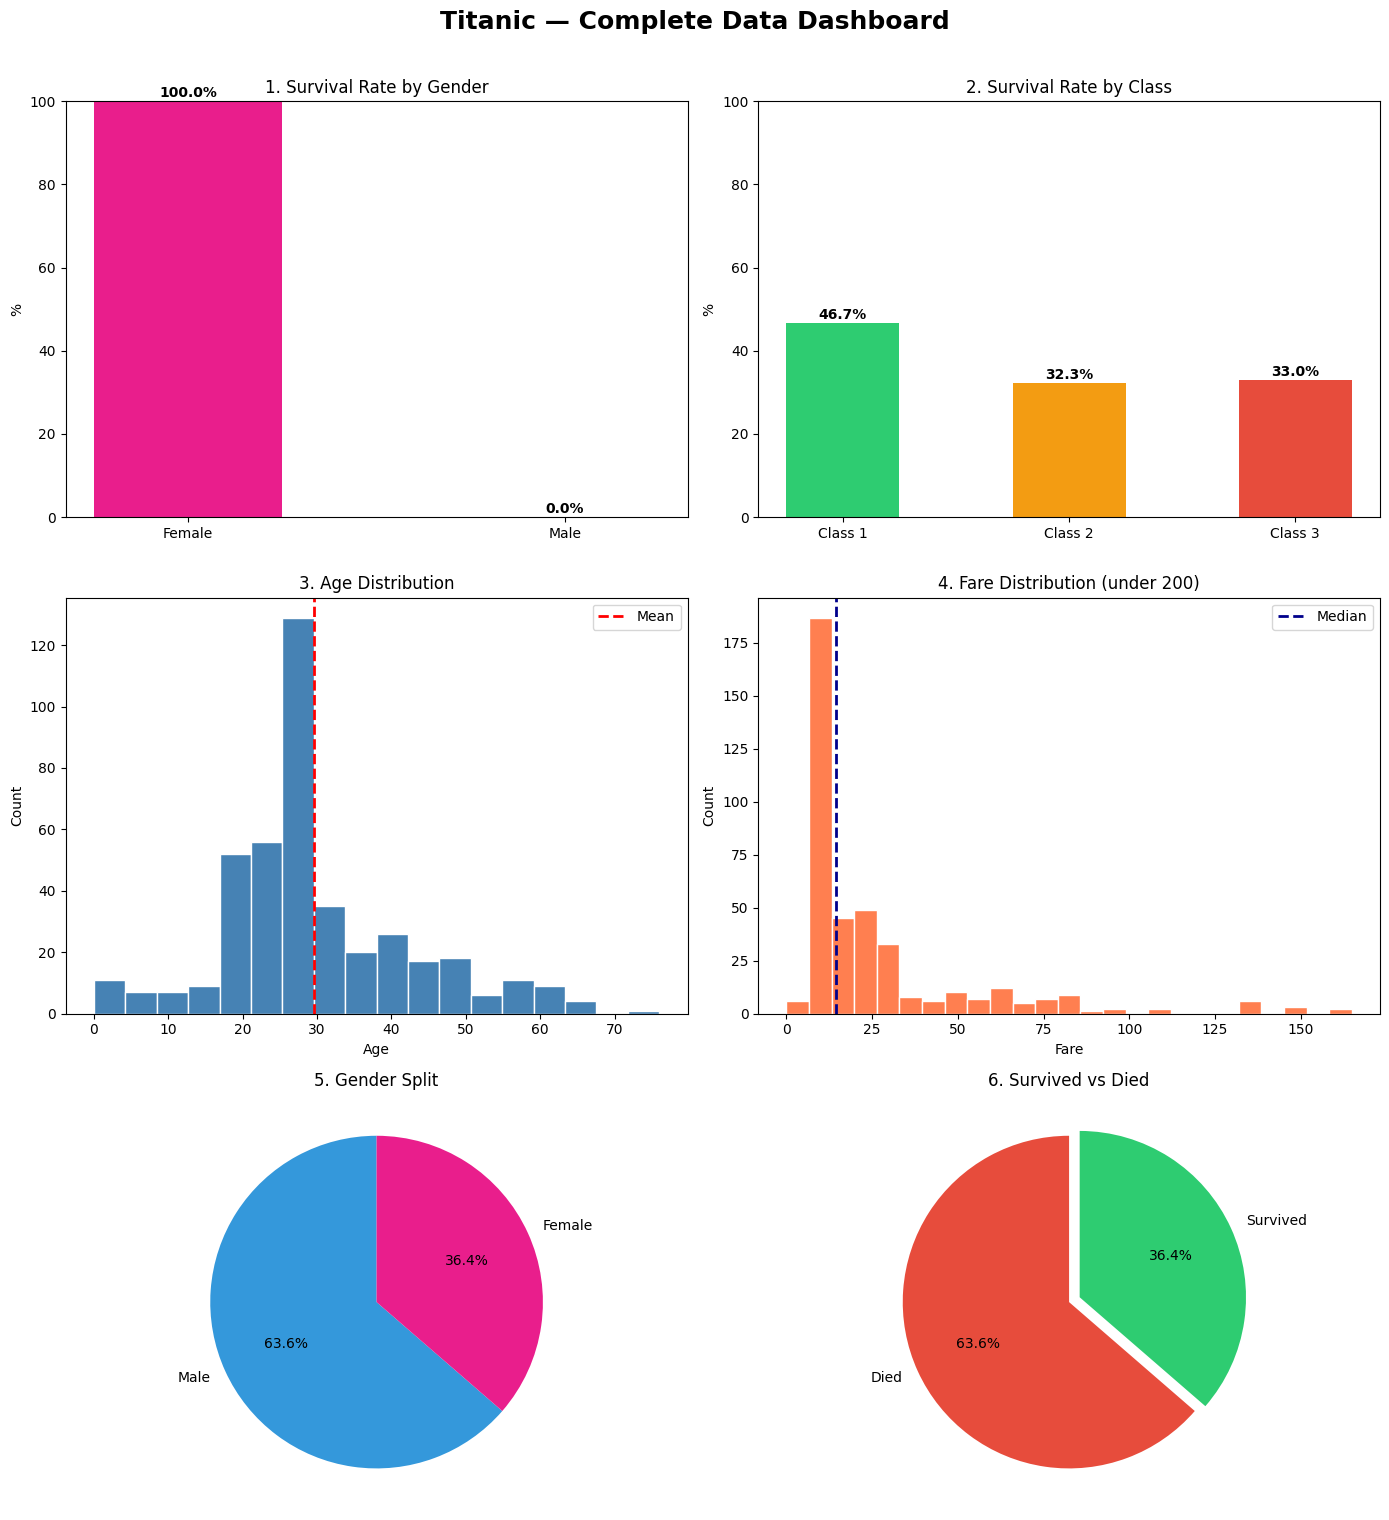

Dashboard saved as titanic_dashboard.png


In [20]:
# Full 6-chart dashboard — 3 rows, 2 columns

plt.figure(figsize=(14, 15))

# --- Chart 1: Survival by Gender ---
plt.subplot(3, 2, 1)
g_surv = df.groupby('Sex')['Survived'].mean() * 100
plt.bar(['Female', 'Male'], g_surv.values, color=['#e91e8c', '#3498db'], width=0.5)
plt.title('1. Survival Rate by Gender')
plt.ylabel('%')
plt.ylim(0, 100)
for i, v in enumerate(g_surv.values):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# --- Chart 2: Survival by Class ---
plt.subplot(3, 2, 2)
c_surv = df.groupby('Pclass')['Survived'].mean() * 100
plt.bar(['Class 1', 'Class 2', 'Class 3'], c_surv.values, color=['#2ecc71','#f39c12','#e74c3c'], width=0.5)
plt.title('2. Survival Rate by Class')
plt.ylabel('%')
plt.ylim(0, 100)
for i, v in enumerate(c_surv.values):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# --- Chart 3: Age Distribution ---
plt.subplot(3, 2, 3)
plt.hist(df['Age'], bins=18, color='steelblue', edgecolor='white')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.title('3. Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()

# --- Chart 4: Fare Distribution ---
plt.subplot(3, 2, 4)
plt.hist(df[df['Fare'] < 200]['Fare'], bins=25, color='coral', edgecolor='white')
plt.axvline(df['Fare'].median(), color='darkblue', linestyle='--', linewidth=2, label='Median')
plt.title('4. Fare Distribution (under 200)')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.legend()

# --- Chart 5: Pie — Gender Split ---
plt.subplot(3, 2, 5)
g_counts = df['Sex'].value_counts()
plt.pie(g_counts.values, labels=['Male','Female'], colors=['#3498db','#e91e8c'],
        autopct='%1.1f%%', startangle=90)
plt.title('5. Gender Split')

# --- Chart 6: Survived vs Died ---
plt.subplot(3, 2, 6)
s_counts = df['Survived'].value_counts()
plt.pie(s_counts.values, labels=['Died','Survived'], colors=['#e74c3c','#2ecc71'],
        autopct='%1.1f%%', startangle=90, explode=(0, 0.07))
plt.title('6. Survived vs Died')

plt.suptitle('Titanic — Complete Data Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('titanic_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as titanic_dashboard.png')

---
## Chart Types We Learned

| Chart Type | Matplotlib Function | When to Use |
|-----------|--------------------|--------------|
| Bar Chart | `plt.bar()` | Compare values across categories |
| Horizontal Bar | `plt.barh()` | When category names are long |
| Pie Chart | `plt.pie()` | Show parts of a whole (%) |
| Line Chart | `plt.plot()` | Show trends over time |
| Histogram | `plt.hist()` | Distribution of one number |
| Scatter Plot | `plt.scatter()` | Relationship between two numbers |
| Grouped Bar | `plt.bar()` with positions | Compare multiple groups side by side |
| Dashboard | `plt.subplot()` | Multiple charts in one figure |

## Key Commands to Remember

| Command | What it does |
|---------|--------------|
| `plt.figure(figsize=(w,h))` | Set chart size |
| `plt.title('...')` | Add title |
| `plt.xlabel('...')` | Label X axis |
| `plt.ylabel('...')` | Label Y axis |
| `plt.legend()` | Show color legend |
| `plt.grid(True)` | Add grid lines |
| `plt.axvline(value)` | Add vertical reference line |
| `plt.tight_layout()` | Fix spacing |
| `plt.savefig('name.png')` | Save chart as image |
| `plt.show()` | Display the chart |

> **Well done! You have now completed Pandas + NumPy + Matplotlib!**
> The next step is using these together to build real business reports.